# SSDC 2026 — Exploratory Data Analysis (EDA): Student Placement System Dataset by kata edward

## Bagian 0 — Setup & Sanity Check

In [132]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

### 0.1 — Konfirmasi Shape

In [133]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

DATA_DIR = "../data/clean/"

company = pd.read_csv(
    DATA_DIR + "company_clean.csv",
    dtype={"id_company": str, "pic_phone": str},
    parse_dates=["created_at"],
)

status_student = pd.read_csv(
    DATA_DIR + "status_student_clean.csv",
    dtype={"id_status": str, "NIM": str, "no_whatsapp": str},
    parse_dates=["sync_date"],
)

student_all = pd.read_csv(
    DATA_DIR + "student_all_clean.csv", dtype={"NIM": str, "hp": str}
)

talent_request = pd.read_csv(
    DATA_DIR + "talent_request_clean.csv",
    dtype={"id_talent_req": str, "id_company": str, "no_whatsapp": str},
    parse_dates=["request_date"],
)

tracking_company = pd.read_csv(
    DATA_DIR + "tracking_company_clean.csv",
    dtype={
        "id_tracking_company": str,
        "id_talent_req": str,
        "id_company": str,
        "list_nim": str,
    },
    parse_dates=["request_date", "send_date"],
)

tracking_student = pd.read_csv(
    DATA_DIR + "tracking_student_clean.csv",
    dtype={"id_tracking_student": str, "NIM": str, "id_tracking_company": str},
    parse_dates=["last_update"],
)

tables = {
    "company": company,
    "talent_request": talent_request,
    "student_all": student_all,
    "status_student": status_student,
    "tracking_company": tracking_company,
    "tracking_student": tracking_student,
}

expected_shapes = {
    "company": 1500,
    "status_student": 25000,
    "student_all": 25000,
    "talent_request": 12000,
    "tracking_company": 12000,
    "tracking_student": 41600,
}

for name in tables:
    n = tables[name].shape[0]
    status = "MISMATCH"
    if n == expected_shapes[name]:
        status = "OK"
    print(
        f"{name:18s} shape={n}  expected_rows={expected_shapes.get(name):<6} [{status}]"
    )

company            shape=1500  expected_rows=1500   [OK]
talent_request     shape=12000  expected_rows=12000  [OK]
student_all        shape=25000  expected_rows=25000  [OK]
status_student     shape=25000  expected_rows=25000  [OK]
tracking_company   shape=12000  expected_rows=12000  [OK]
tracking_student   shape=41600  expected_rows=41600  [OK]


### 0.2 — Sanity Check Ringkas (PK, FK, tanggal)

In [134]:
pk_checks = {
    "company": "id_company",
    "status_student": "id_status",
    "student_all": "NIM",
    "talent_request": "id_talent_req",
    "tracking_company": "id_tracking_company",
    "tracking_student": "id_tracking_student",
}

print("-- Primary key unik -- ")
for name, pk in pk_checks.items():
    df = tables[name]
    dup = df[pk].duplicated().sum()
    print(f"{name:18s} PK={pk:20s} duplikat={dup} [{'OK' if dup==0 else 'ANOMALI'}]")


print("\n-- Foreign key yatim (orphan) --")

# fmt: off
orphan_ss_nim = ~status_student["NIM"].isin(student_all["NIM"])
orphan_tr_company = ~talent_request["id_company"].isin(company["id_company"])
orphan_tc_talent = ~tracking_company["id_talent_req"].isin(talent_request["id_talent_req"])
orphan_tc_company = ~tracking_company["id_company"].isin(company["id_company"])
orphan_ts_tc = ~tracking_student["id_tracking_company"].isin(tracking_company["id_tracking_company"])
orphan_ts_nim = ~tracking_student["NIM"].isin(student_all["NIM"])

print(f"status_student.NIM -> student_all.NIM : {orphan_ss_nim.sum()} yatim")
print(f"talent_request.id_company -> company.id_company : {orphan_tr_company.sum()} yatim")
print(f"tracking_company.id_talent_req -> talent_request.id_talent_req : {orphan_tc_talent.sum()} yatim")
print(f"tracking_company.id_company -> company.id_company : {orphan_tc_company.sum()} yatim")
print(f"tracking_student.id_tracking_company -> tracking_company.id_tracking_company : {orphan_ts_tc.sum()} yatim")
print(f"tracking_student.NIM -> student_all.NIM : {orphan_ts_nim.sum()} yatim")
# fmt: on


print("\n-- Draft tracking_company (expected 598) --")
draft_mask = tracking_company["send_date"].isna() & tracking_company["list_nim"].isna()
print(f"Baris tanpa send_date & list_nim: {draft_mask.sum()}")
print(tracking_company.loc[draft_mask, "progress"].value_counts())


print("\n-- Rentang tanggal --")
date_cols = {
    "company.created_at": company["created_at"],
    "talent_request.request_date": talent_request["request_date"],
    "status_student.sync_date": status_student["sync_date"],
    "tracking_company.request_date": tracking_company["request_date"],
    "tracking_company.send_date": tracking_company["send_date"],
    "tracking_student.last_update": tracking_student["last_update"],
}

for label, col in date_cols.items():
    print(f"{label:30s} min={col.min().date()}  max={col.max().date()}")

sent = tracking_company.dropna(subset=["send_date"])
invalid_order = (sent["send_date"] < sent["request_date"]).sum()
print(f"\ntracking_company.send_date < tracking_company.request_date (harus 0): {invalid_order}")  # fmt: skip

-- Primary key unik -- 
company            PK=id_company           duplikat=0 [OK]
status_student     PK=id_status            duplikat=0 [OK]
student_all        PK=NIM                  duplikat=0 [OK]
talent_request     PK=id_talent_req        duplikat=0 [OK]
tracking_company   PK=id_tracking_company  duplikat=0 [OK]
tracking_student   PK=id_tracking_student  duplikat=0 [OK]

-- Foreign key yatim (orphan) --
status_student.NIM -> student_all.NIM : 0 yatim
talent_request.id_company -> company.id_company : 0 yatim
tracking_company.id_talent_req -> talent_request.id_talent_req : 0 yatim
tracking_company.id_company -> company.id_company : 0 yatim
tracking_student.id_tracking_company -> tracking_company.id_tracking_company : 0 yatim
tracking_student.NIM -> student_all.NIM : 0 yatim

-- Draft tracking_company (expected 598) --
Baris tanpa send_date & list_nim: 598
progress
Draft    598
Name: count, dtype: int64

-- Rentang tanggal --
company.created_at             min=2022-01-02  max=2024-12

### 0.2b — Cross-check STUDENT ALL ↔ STATUS STUDENT (BT-08)

In [135]:
merged = student_all.merge(
    status_student[["NIM", "nama", "program_studi", "semester"]],
    on="NIM",
    how="outer",
    suffixes=("_studentall", "_status"),
    indicator=True,
)

# fmt: off
orphan_left = (merged['_merge'] == 'left_only').sum()   # ada di student_all, tidak di status_student
orphan_right = (merged['_merge'] == 'right_only').sum() # ada di status_student, tidak di student_all
print(f"NIM hanya di student_all (orphan)   : {orphan_left}")
print(f"NIM hanya di status_student (orphan): {orphan_right}")

both = merged[merged['_merge'] == 'both'].copy()
mismatch_nama = (both['nama_studentall'] != both['nama_status']).sum()
mismatch_prodi = (both['program_studi_studentall'] != both['program_studi_status']).sum()
mismatch_semester = (both['semester_studentall'] != both['semester_status']).sum()

print(f"\nDari {len(both)} NIM yang match di kedua tabel:")
print(f"  mismatch nama         : {mismatch_nama}")
print(f"  mismatch program_studi: {mismatch_prodi}")
print(f"  mismatch semester     : {mismatch_semester}")

kesimpulan = "SINKRON 100%" if (orphan_left + orphan_right + mismatch_nama + mismatch_prodi + mismatch_semester) == 0 else "ADA ANOMALI"
print(f"\n>>> Kesimpulan 0.2b: {kesimpulan}")
# fmt: on

NIM hanya di student_all (orphan)   : 0
NIM hanya di status_student (orphan): 0

Dari 25000 NIM yang match di kedua tabel:
  mismatch nama         : 0
  mismatch program_studi: 0
  mismatch semester     : 0

>>> Kesimpulan 0.2b: SINKRON 100%


## Bagian 1 — Profil Dasar Tiap Tabel → H1

In [136]:
def bar_with_labels(ax, series, title, rotation=0, palette="Set1"):
    sns.barplot(
        x=series.index.astype(str),
        y=series.values,
        hue=series.index.astype(str),
        palette=palette,
        legend=False,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=rotation)
    ax.set_ylim(0, series.max() * 1.15)
    ax.margins(x=0.05)
    for container in ax.containers:
        ax.bar_label(container, padding=3)


def hist_with_labels(ax, data, title, bins=20, color=None):
    sns.histplot(data, bins=bins, ax=ax, color=color)
    ax.set_title(title)
    ax.set_xlabel("")

    max_bin_height = max(v for container in ax.containers for v in container.datavalues)
    ax.set_ylim(0, max_bin_height * 1.15)

    for container in ax.containers:
        labels = [f"{int(v)}" if v > 0 else "" for v in container.datavalues]
        ax.bar_label(container, labels=labels, padding=3, fontsize=8)


def print_summary(label, counts, unit="perusahaan"):
    print(f"{label}:")
    print(f"   dominan : {counts.idxmax()} ({counts.max()} {unit})")
    print(f"   sedikit : {counts.idxmin()} ({counts.min()} {unit})")
    print()

### 1.1 — Profil company

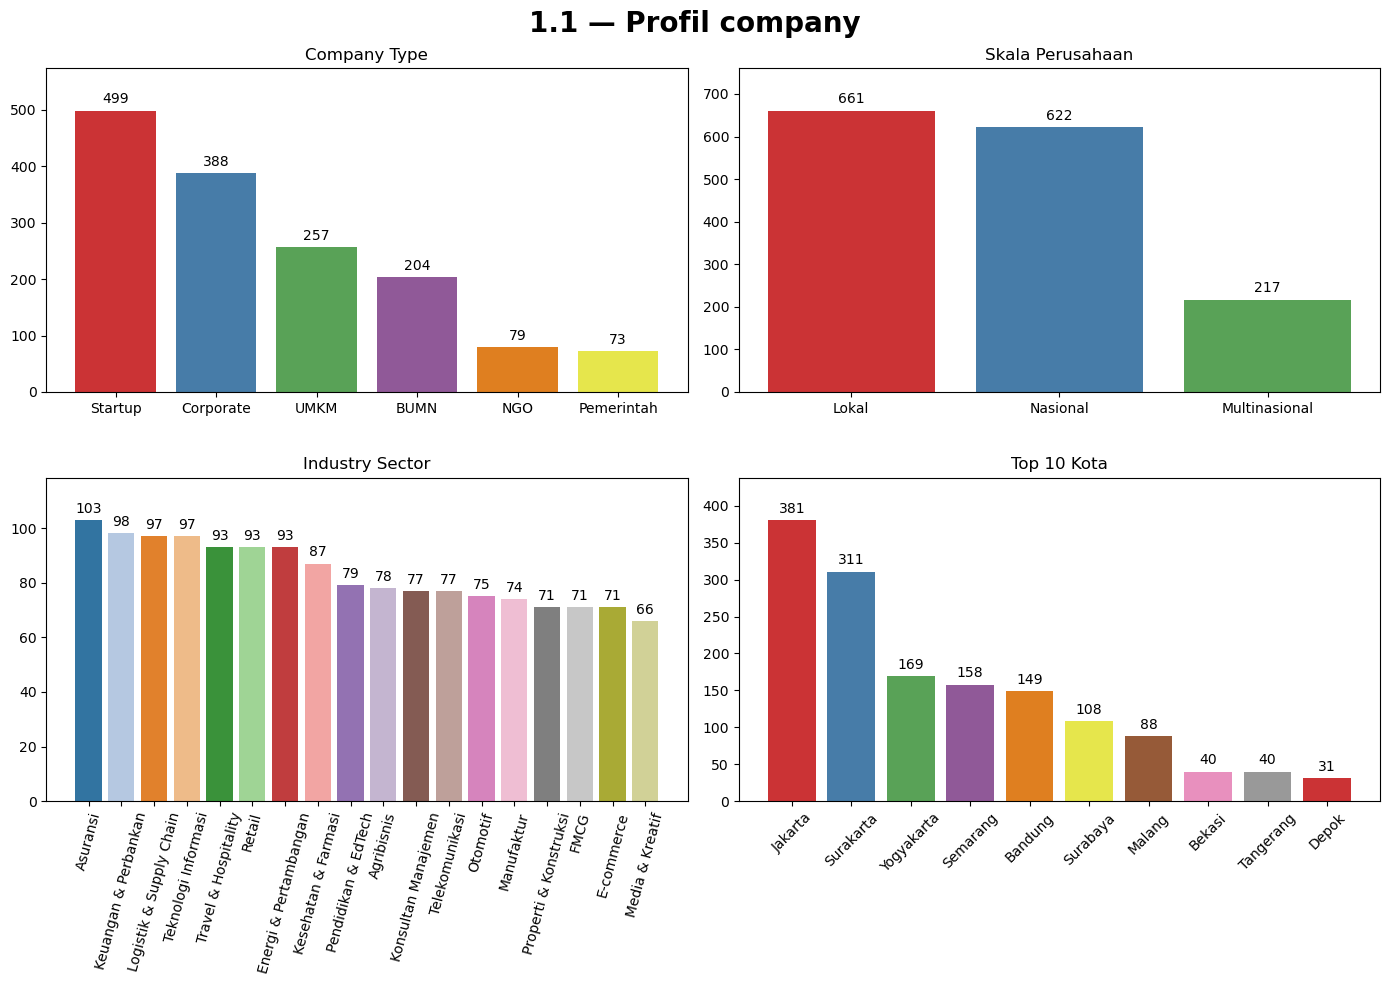

company_type:
   dominan : Startup (499 perusahaan)
   sedikit : Pemerintah (73 perusahaan)

skala_perusahaan:
   dominan : Lokal (661 perusahaan)
   sedikit : Multinasional (217 perusahaan)

industry_sector:
   dominan : Asuransi (103 perusahaan)
   sedikit : Media & Kreatif (66 perusahaan)

kota:
   dominan : Jakarta (381 perusahaan)
   sedikit : Bogor (25 perusahaan)

jumlah kota unik: 11
daftar lengkap per kota:
   Jakarta        : 381 perusahaan
   Surakarta      : 311 perusahaan
   Yogyakarta     : 169 perusahaan
   Semarang       : 158 perusahaan
   Bandung        : 149 perusahaan
   Surabaya       : 108 perusahaan
   Malang         : 88 perusahaan
   Bekasi         : 40 perusahaan
   Tangerang      : 40 perusahaan
   Depok          : 31 perusahaan
   Bogor          : 25 perusahaan


In [137]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("1.1 — Profil company", fontsize=20, fontweight="bold")


# fmt: off
bar_with_labels(axes[0, 0], company["company_type"].value_counts(), "Company Type")
bar_with_labels(axes[0, 1], company["skala_perusahaan"].value_counts(), "Skala Perusahaan")
bar_with_labels(axes[1, 0], company["industry_sector"].value_counts(), "Industry Sector", rotation=75, palette="tab20")
bar_with_labels(axes[1, 1], company["kota"].value_counts().head(10), "Top 10 Kota", rotation=45)
# fmt: on

plt.tight_layout(h_pad=3)
plt.show()


company_type_counts = company["company_type"].value_counts()
skala_counts = company["skala_perusahaan"].value_counts()
sector_counts = company["industry_sector"].value_counts()
kota_counts = company["kota"].value_counts()

print_summary("company_type", company_type_counts)
print_summary("skala_perusahaan", skala_counts)
print_summary("industry_sector", sector_counts)
print_summary("kota", kota_counts)

print(f"jumlah kota unik: {company['kota'].nunique()}")
print("daftar lengkap per kota:")
for kota, jumlah in kota_counts.items():
    print(f"   {kota:15s}: {jumlah} perusahaan")

### 1.2 — Profil talent_request

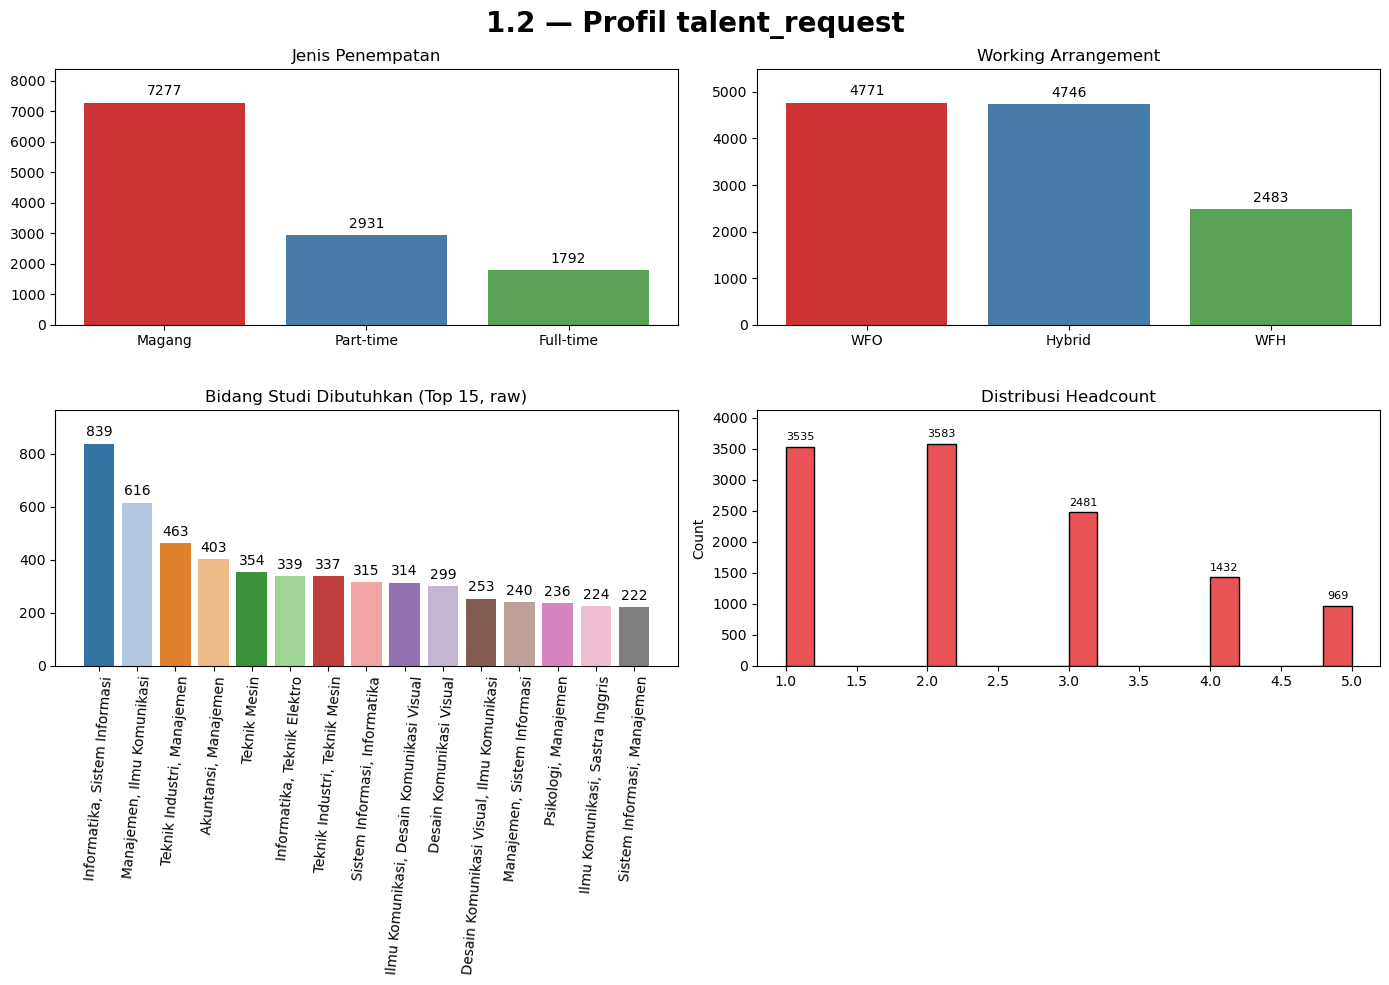

jenis_penempatan:
   dominan : Magang (7277 perusahaan)
   sedikit : Full-time (1792 perusahaan)

working_arrangement:
   dominan : WFO (4771 perusahaan)
   sedikit : WFH (2483 perusahaan)

bidang_studi_dibutuhkan: 113 kombinasi unik (raw, belum di-explode)
   dominan : Informatika, Sistem Informasi (839 request)
   catatan : analisis 'bidang paling jarang' lebih valid setelah explode (bagian supply-demand)

headcount describe():
count    12000.000000
mean         2.393083
std          1.245404
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          5.000000
Name: headcount, dtype: float64


In [138]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("1.2 — Profil talent_request", fontsize=20, fontweight="bold")

bidang_studi_counts_full = talent_request["bidang_studi_dibutuhkan"].value_counts()

# fmt: off
bar_with_labels(axes[0, 0], talent_request["jenis_penempatan"].value_counts(), "Jenis Penempatan")
bar_with_labels(axes[0, 1], talent_request["working_arrangement"].value_counts(), "Working Arrangement")
bar_with_labels(axes[1, 0], bidang_studi_counts_full.head(15), "Bidang Studi Dibutuhkan (Top 15, raw)", rotation=85, palette="tab20")
hist_with_labels(axes[1, 1], talent_request["headcount"], "Distribusi Headcount", bins=20, color=sns.color_palette("Set1")[0])

plt.tight_layout(h_pad=3)
plt.show()

print_summary("jenis_penempatan", talent_request["jenis_penempatan"].value_counts())
print_summary("working_arrangement", talent_request["working_arrangement"].value_counts())

print(f"bidang_studi_dibutuhkan: {len(bidang_studi_counts_full)} kombinasi unik (raw, belum di-explode)")
print(f"   dominan : {bidang_studi_counts_full.idxmax()} ({bidang_studi_counts_full.max()} request)")
print(f"   catatan : analisis 'bidang paling jarang' lebih valid setelah explode (bagian supply-demand)")
print()
# fmt: on

print("headcount describe():")
print(talent_request["headcount"].describe())

### 1.3 — Profil student_all

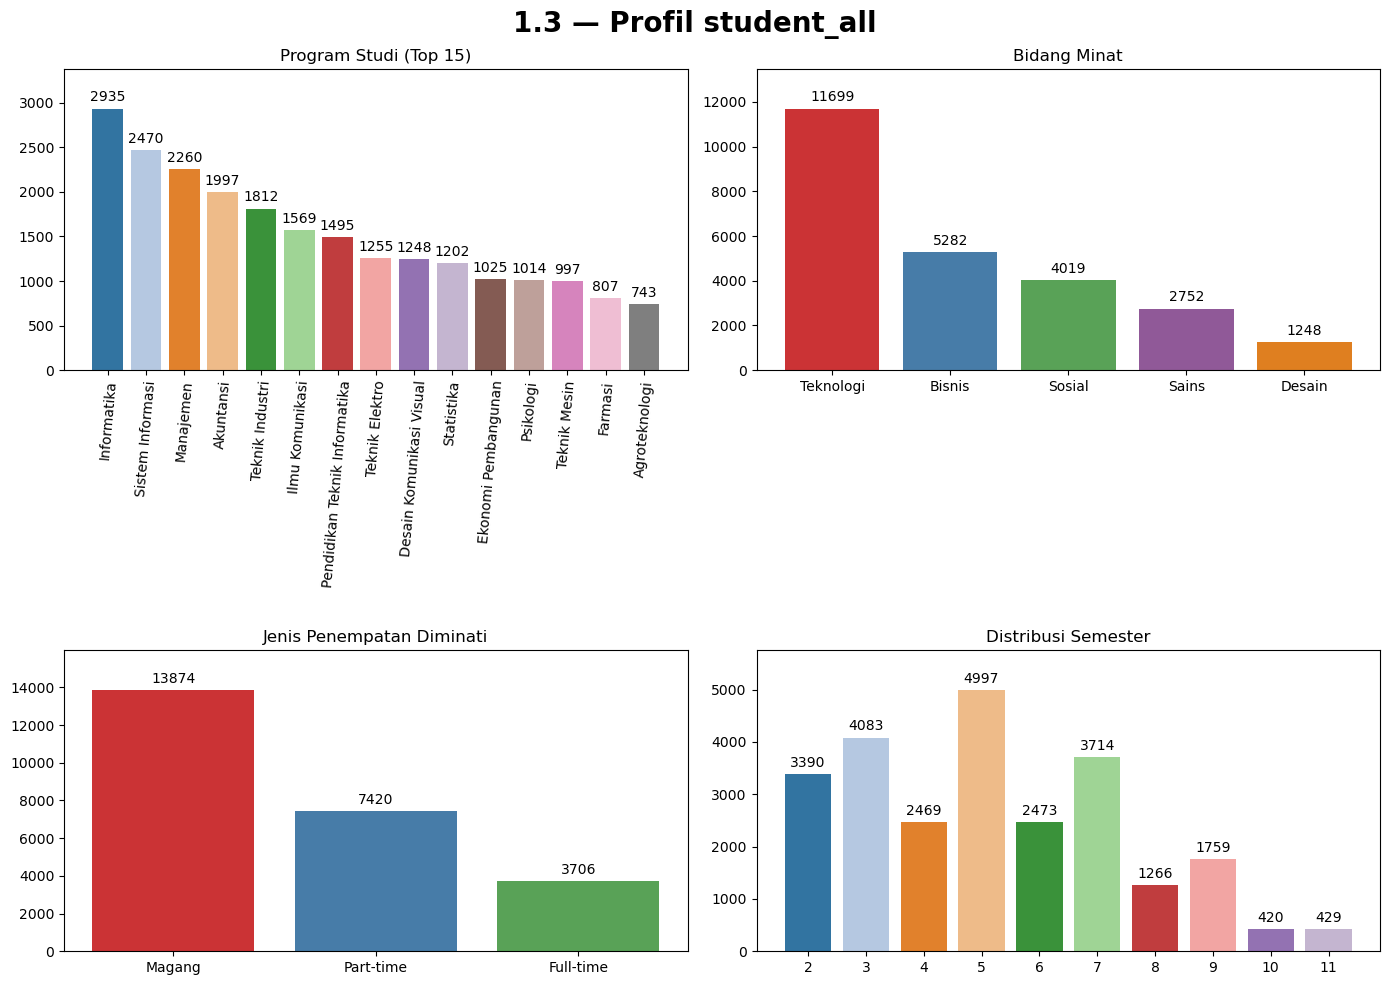

program_studi: 18 prodi unik
   terbesar : Informatika (2935 mahasiswa)
   terkecil : Ilmu Hukum (700 mahasiswa)

bidang_minat:
   dominan : Teknologi (11699 mahasiswa)
   sedikit : Desain (1248 mahasiswa)

jenis_penempatan_diminati:
   dominan : Magang (13874 mahasiswa)
   sedikit : Full-time (3706 mahasiswa)

Distribusi semester (urut semester, bukan frekuensi):
   semester  2: 3390 mahasiswa
   semester  3: 4083 mahasiswa
   semester  4: 2469 mahasiswa
   semester  5: 4997 mahasiswa
   semester  6: 2473 mahasiswa
   semester  7: 3714 mahasiswa
   semester  8: 1266 mahasiswa
   semester  9: 1759 mahasiswa
   semester 10: 420 mahasiswa
   semester 11: 429 mahasiswa


In [139]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("1.3 — Profil student_all", fontsize=20, fontweight="bold")

program_studi_counts_full = student_all["program_studi"].value_counts()
semester_counts = student_all["semester"].value_counts().sort_index()

# fmt:off
bar_with_labels(axes[0, 0], program_studi_counts_full.head(15), "Program Studi (Top 15)", rotation=85, palette="tab20")
bar_with_labels(axes[0, 1], student_all["bidang_minat"].value_counts(), "Bidang Minat")
bar_with_labels(axes[1, 0], student_all["jenis_penempatan_diminati"].value_counts(), "Jenis Penempatan Diminati")
bar_with_labels(axes[1, 1], semester_counts, "Distribusi Semester", palette="tab20")

plt.tight_layout(h_pad=3)
plt.show()

print(f"program_studi: {len(program_studi_counts_full)} prodi unik")
print(f"   terbesar : {program_studi_counts_full.idxmax()} ({program_studi_counts_full.max()} mahasiswa)")
print(f"   terkecil : {program_studi_counts_full.idxmin()} ({program_studi_counts_full.min()} mahasiswa)")
print()

print_summary("bidang_minat", student_all["bidang_minat"].value_counts(), unit="mahasiswa")
print_summary("jenis_penempatan_diminati", student_all["jenis_penempatan_diminati"].value_counts(), unit="mahasiswa")
# fmt:on

print("Distribusi semester (urut semester, bukan frekuensi):")
for sem, jumlah in semester_counts.items():
    print(f"   semester {sem:2d}: {jumlah} mahasiswa")

### 1.4 — Profil status_student

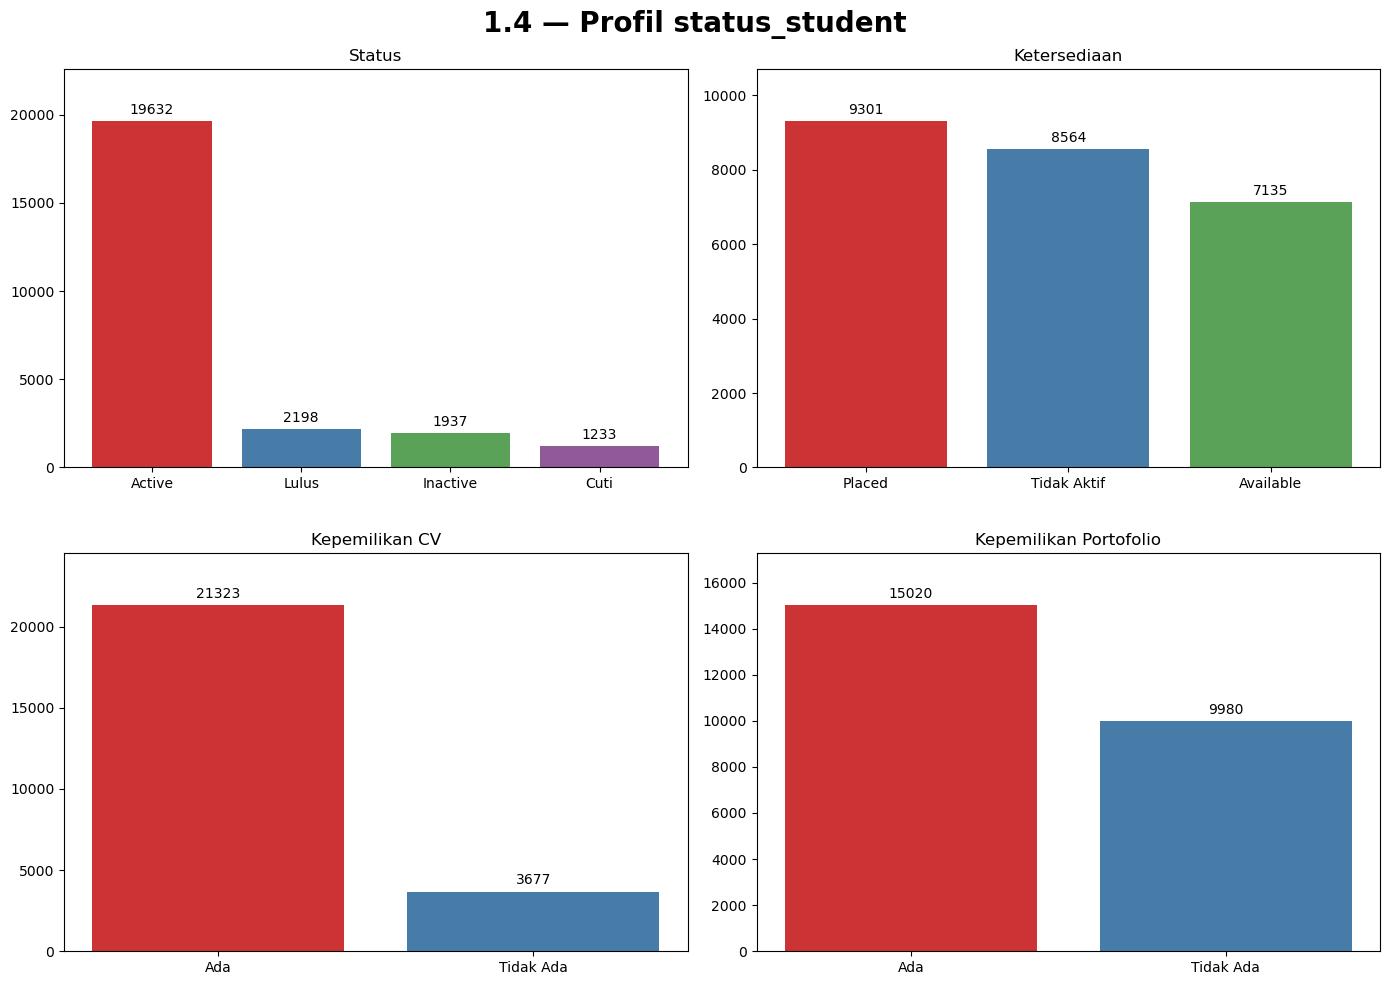

status:
   dominan : Active (19632 mahasiswa)
   sedikit : Cuti (1233 mahasiswa)

ketersediaan:
   dominan : Placed (9301 mahasiswa)
   sedikit : Available (7135 mahasiswa)

CV:
   dominan : Ada (21323 mahasiswa)
   sedikit : Tidak Ada (3677 mahasiswa)

portofolio:
   dominan : Ada (15020 mahasiswa)
   sedikit : Tidak Ada (9980 mahasiswa)



In [140]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("1.4 — Profil status_student", fontsize=20, fontweight="bold")

# fmt:off
bar_with_labels(axes[0, 0], status_student["status"].value_counts(), "Status")
bar_with_labels(axes[0, 1], status_student["ketersediaan"].value_counts(), "Ketersediaan")
bar_with_labels(axes[1, 0], status_student["CV"].value_counts(), "Kepemilikan CV")
bar_with_labels(axes[1, 1], status_student["portofolio"].value_counts(), "Kepemilikan Portofolio")

plt.tight_layout(h_pad=3)
plt.show()

print_summary("status", status_student["status"].value_counts(), unit="mahasiswa")
print_summary("ketersediaan", status_student["ketersediaan"].value_counts(), unit="mahasiswa")
print_summary("CV", status_student["CV"].value_counts(), unit="mahasiswa")
print_summary("portofolio", status_student["portofolio"].value_counts(), unit="mahasiswa")
# fmt:on

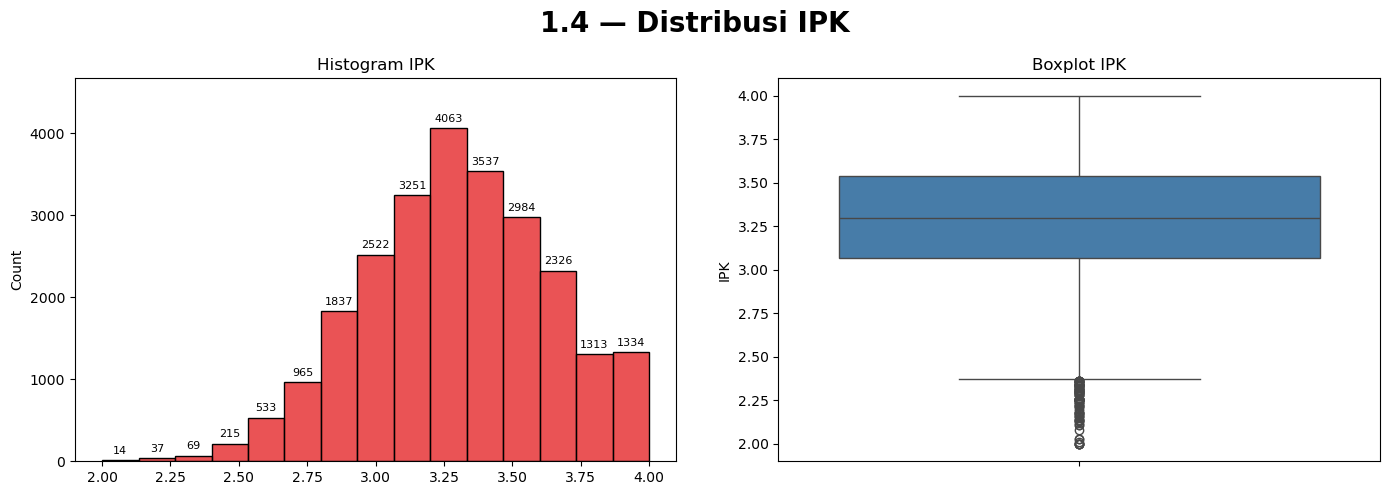

IPK describe():
count    25000.000000
mean         3.298299
std          0.341807
min          2.000000
25%          3.070000
50%          3.300000
75%          3.540000
max          4.000000
Name: IPK, dtype: float64

Breakdown per rentang IPK (bin 0.2):
   (1.999, 2.2] : 28 mahasiswa
   (2.2, 2.4] : 97 mahasiswa
   (2.4, 2.6] : 442 mahasiswa
   (2.6, 2.8] : 1370 mahasiswa
   (2.8, 3.0] : 2959 mahasiswa
   (3.0, 3.2] : 4840 mahasiswa
   (3.2, 3.4] : 5752 mahasiswa
   (3.4, 3.6] : 4708 mahasiswa
   (3.6, 3.8] : 2965 mahasiswa
   (3.8, 4.0] : 1839 mahasiswa


In [141]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("1.4 — Distribusi IPK", fontsize=20, fontweight="bold")

hist_with_labels(
    axes[0],
    status_student["IPK"],
    "Histogram IPK",
    bins=15,
    color=sns.color_palette("Set1")[0],
)

sns.boxplot(y=status_student["IPK"], ax=axes[1], color=sns.color_palette("Set1")[1])
axes[1].set_title("Boxplot IPK")

plt.tight_layout(w_pad=3)
plt.show()

print("IPK describe():")
print(status_student["IPK"].describe())

print("\nBreakdown per rentang IPK (bin 0.2):")
bin_edges = np.arange(2.0, 4.01, 0.2)
ipk_binned = pd.cut(status_student["IPK"], bins=bin_edges, include_lowest=True)
for interval, jumlah in ipk_binned.value_counts().sort_index().items():
    print(f"   {interval} : {jumlah} mahasiswa")

### 1.5 — Rentang tanggal semua tabel

In [142]:
date_summary = pd.DataFrame(
    {
        "tabel.kolom": [
            "company.created_at",
            "talent_request.request_date",
            "status_student.sync_date",
            "tracking_company.request_date",
            "tracking_company.send_date",
            "tracking_student.last_update",
        ],
        "min": [
            company["created_at"].min(),
            talent_request["request_date"].min(),
            status_student["sync_date"].min(),
            tracking_company["request_date"].min(),
            tracking_company["send_date"].min(),
            tracking_student["last_update"].min(),
        ],
        "max": [
            company["created_at"].max(),
            talent_request["request_date"].max(),
            status_student["sync_date"].max(),
            tracking_company["request_date"].max(),
            tracking_company["send_date"].max(),
            tracking_student["last_update"].max(),
        ],
    }
)

date_summary["rentang_hari"] = (date_summary["max"] - date_summary["min"]).dt.days

date_summary

,tabel.kolom,min,max,rentang_hari
0,company.created_at,2022-01-02,2024-12-31,1094
1,talent_request.request_date,2023-02-01,2025-01-31,730
2,status_student.sync_date,2023-02-01,2025-01-31,730
3,tracking_company.request_date,2023-02-01,2025-01-31,730
4,tracking_company.send_date,2023-02-04,2025-02-21,748
5,tracking_student.last_update,2023-02-08,2025-05-17,829


## Bagian 2 — Kelayakan Mahasiswa & Audit Kepatuhan (BT-06) → H1

### 2.1 — Funnel kelayakan bertingkat

Total Terdaftar             : 25,000  (100.0% dari total)
status = Active             : 19,632  ( 78.5% dari total)   retensi 78.5%   drop -5,368 (-21.5%)
+ CV = Ada                  : 16,732  ( 66.9% dari total)   retensi 85.2%   drop -2,900 (-14.8%)
+ ketersediaan = Available  :  5,687  ( 22.7% dari total)   retensi 34.0%   drop -11,045 (-66.0%)

>>> Penyusutan terbesar: '+ ketersediaan = Available' (-11,045, -66.0%)


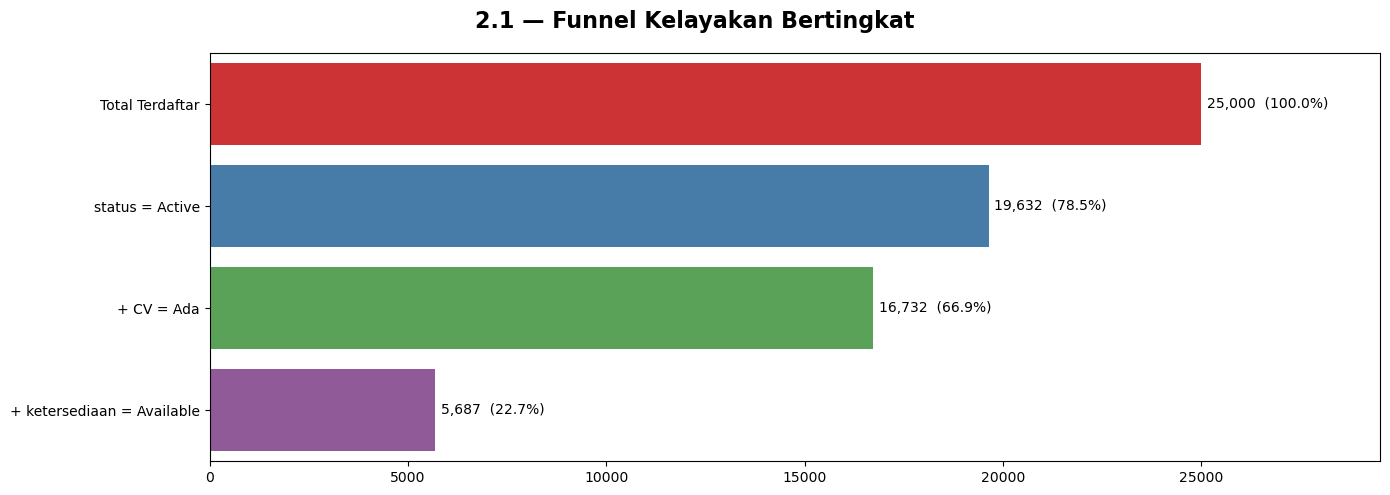

In [143]:
stage1_mask = pd.Series(True, index=status_student.index)
stage2_mask = stage1_mask & (status_student["status"] == "Active")
stage3_mask = stage2_mask & (status_student["CV"] == "Ada")
stage4_mask = stage3_mask & (status_student["ketersediaan"] == "Available")

funnel_stages = [
    ("Total Terdaftar", stage1_mask.sum()),
    ("status = Active", stage2_mask.sum()),
    ("+ CV = Ada", stage3_mask.sum()),
    ("+ ketersediaan = Available", stage4_mask.sum()),
]

total = funnel_stages[0][1]
funnel_df = pd.DataFrame(funnel_stages, columns=["tahap", "jumlah"])

# -- Ringkasan --
prev = None
drops = []
for label, count in funnel_stages:
    pct = count / total * 100
    if prev is None:
        print(f"{label:28s}: {count:6,d}  ({pct:5.1f}% dari total)")
    else:
        drop = prev - count
        pct_drop = drop / prev * 100
        pct_retain = count / prev * 100
        drops.append((label, drop, pct_drop))
        print(
            f"{label:28s}: {count:6,d}  ({pct:5.1f}% dari total)   retensi {pct_retain:.1f}%   drop -{drop:,} (-{pct_drop:.1f}%)"
        )
    prev = count

terbesar = max(drops, key=lambda x: x[1])
print(
    f"\n>>> Penyusutan terbesar: '{terbesar[0]}' (-{terbesar[1]:,}, -{terbesar[2]:.1f}%)"
)

# -- Chart --
fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle("2.1 — Funnel Kelayakan Bertingkat", fontsize=16, fontweight="bold")

sns.barplot(
    data=funnel_df,
    x="jumlah",
    y="tahap",
    hue="tahap",
    palette="Set1",
    legend=False,
    ax=ax,
)

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xlim(0, total * 1.18)

for container in ax.containers:
    labels_txt = [f"{v:,.0f}  ({v/total*100:.1f}%)" for v in container.datavalues]
    ax.bar_label(container, labels=labels_txt, padding=4, fontsize=10)

plt.tight_layout()
plt.show()

### 2.2 — Asumsi IPK threshold (dokumentasikan eksplisit)

In [144]:
eligible_mask = status_student["eligible"] = (
    (status_student["status"] == "Active")
    & (status_student["CV"] == "Ada")
    & (status_student["ketersediaan"] == "Available")
)
eligible_base = eligible_mask.sum()
total = len(status_student)

thresholds = [None, 2.5, 2.75, 3.0]
threshold_labels = ["Tanpa filter (>=2.0, default)", ">=2.5", ">=2.75", ">=3.0"]

print(
    f"Basis: populasi eligible dari funnel 2.1 (Active+CV+Available) = {eligible_base:,} mahasiswa\n"
)

results = []
for label, thresh in zip(threshold_labels, thresholds):
    mask = (
        eligible_mask
        if thresh is None
        else eligible_mask & (status_student["IPK"] >= thresh)
    )
    count = mask.sum()
    pct_of_eligible = count / eligible_base * 100
    pct_of_total = count / total * 100
    results.append((label, count, pct_of_eligible, pct_of_total))
    print(
        f"{label:32s}: {count:6,d}  ({pct_of_eligible:5.1f}% dari eligible, {pct_of_total:5.1f}% dari total 25.000)"
    )

sensitivity_df = pd.DataFrame(
    results,
    columns=["threshold_ipk", "jumlah_eligible", "%_dari_eligible", "%_dari_total"],
)
sensitivity_df

Basis: populasi eligible dari funnel 2.1 (Active+CV+Available) = 5,687 mahasiswa

Tanpa filter (>=2.0, default)   :  5,687  (100.0% dari eligible,  22.7% dari total 25.000)
>=2.5                           :  5,622  ( 98.9% dari eligible,  22.5% dari total 25.000)
>=2.75                          :  5,359  ( 94.2% dari eligible,  21.4% dari total 25.000)
>=3.0                           :  4,616  ( 81.2% dari eligible,  18.5% dari total 25.000)


,threshold_ipk,jumlah_eligible,%_dari_eligible,%_dari_total
0,"Tanpa filter (>=2.0, default)",5687,100.000000,22.748
1,>=2.5,5622,98.857042,22.488
2,>=2.75,5359,94.232460,21.436
3,>=3.0,4616,81.167575,18.464


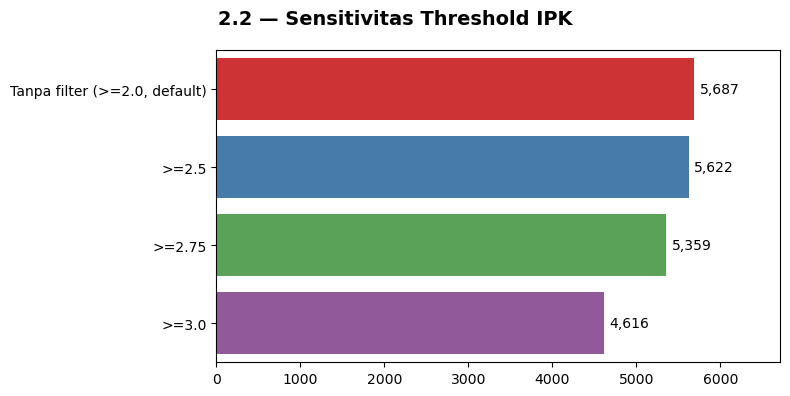


CATATAN KEPUTUSAN — Threshold IPK:

Funnel kelayakan utama (2.1) TIDAK menerapkan filter IPK — semua mahasiswa
dengan IPK >= 2.0 (skala minimum) dianggap valid secara default. Dokumentasi
dataset tidak memberi angka IPK minimum resmi ("Beberapa perusahaan memiliki
syarat IPK minimum" -- kondisional per perusahaan, bukan syarat universal,
sama seperti kasus portofolio).

Tabel di atas murni analisis SENSITIVITAS -- menunjukkan berapa banyak
mahasiswa yang akan "gugur" jika threshold IPK tertentu diterapkan,
BUKAN rekomendasi threshold yang harus dipakai.



In [145]:
fig, ax = plt.subplots(figsize=(8, 4))
fig.suptitle("2.2 — Sensitivitas Threshold IPK", fontsize=14, fontweight="bold")

sns.barplot(
    data=sensitivity_df,
    x="jumlah_eligible",
    y="threshold_ipk",
    hue="threshold_ipk",
    palette="Set1",
    legend=False,
    ax=ax,
)

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xlim(0, eligible_base * 1.18)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{v:,.0f}" for v in container.datavalues],
        padding=4,
        fontsize=10,
    )

plt.tight_layout()
plt.show()

print(
    """
CATATAN KEPUTUSAN — Threshold IPK:

Funnel kelayakan utama (2.1) TIDAK menerapkan filter IPK — semua mahasiswa
dengan IPK >= 2.0 (skala minimum) dianggap valid secara default. Dokumentasi
dataset tidak memberi angka IPK minimum resmi ("Beberapa perusahaan memiliki
syarat IPK minimum" -- kondisional per perusahaan, bukan syarat universal,
sama seperti kasus portofolio).

Tabel di atas murni analisis SENSITIVITAS -- menunjukkan berapa banyak
mahasiswa yang akan "gugur" jika threshold IPK tertentu diterapkan,
BUKAN rekomendasi threshold yang harus dipakai.
"""
)

### 2.3 — AUDIT BT-06: apakah yang DIKIRIM memang eligible? [✓data]

In [146]:
sent_nim = tracking_student["NIM"].unique()
n_sent = len(sent_nim)

sent_status = status_student[status_student["NIM"].isin(sent_nim)].copy()

print(f"Jumlah mahasiswa unik yang pernah dikirim (dari tracking_student): {n_sent:,}")
print(f"Jumlah yang berhasil di-match ke status_student: {len(sent_status):,}\n")

non_active = (sent_status["status"] != "Active").sum()
no_cv = (sent_status["CV"] != "Ada").sum()
not_available = (sent_status["ketersediaan"] != "Available").sum()

audit_df = pd.DataFrame(
    {
        "syarat": ["status = Active", "CV = Ada", "ketersediaan = Available"],
        "jumlah_pelanggaran": [non_active, no_cv, not_available],
        "%_dari_terkirim": [
            non_active / n_sent * 100,
            no_cv / n_sent * 100,
            not_available / n_sent * 100,
        ],
    }
)
print(audit_df.to_string(index=False))

print(
    f"\n>>> Kepatuhan status+CV: {'100% PATUH' if non_active == 0 and no_cv == 0 else 'ADA PELANGGARAN'}"
)

Jumlah mahasiswa unik yang pernah dikirim (dari tracking_student): 10,174
Jumlah yang berhasil di-match ke status_student: 10,174

                  syarat  jumlah_pelanggaran  %_dari_terkirim
         status = Active                   0         0.000000
                CV = Ada                   0         0.000000
ketersediaan = Available                5138        50.501278

>>> Kepatuhan status+CV: 100% PATUH


In [147]:
not_available_mask = sent_status["ketersediaan"] != "Available"
ketersediaan_breakdown = sent_status.loc[
    not_available_mask, "ketersediaan"
].value_counts()

print(
    f"Breakdown ketersediaan untuk {not_available_mask.sum():,} mahasiswa terkirim yang statusnya BUKAN Available:\n"
)
print(ketersediaan_breakdown)

pct_placed = (ketersediaan_breakdown.get("Placed", 0) / not_available_mask.sum()) * 100
print(f"\n>>> {pct_placed:.1f}% dari mereka berstatus 'Placed' saat ini")

if pct_placed == 100:
    print(">>> Kesimpulan: SEMUA non-Available itu justru karena SUDAH placement,")
    print("    bukan pelanggaran matching. Snapshot ketersediaan berubah SETELAH")
    print("    penempatan, bukan bukti CDC mengirim kandidat yang belum siap.")

Breakdown ketersediaan untuk 5,138 mahasiswa terkirim yang statusnya BUKAN Available:

ketersediaan
Placed    5138
Name: count, dtype: int64

>>> 100.0% dari mereka berstatus 'Placed' saat ini
>>> Kesimpulan: SEMUA non-Available itu justru karena SUDAH placement,
    bukan pelanggaran matching. Snapshot ketersediaan berubah SETELAH
    penempatan, bukan bukti CDC mengirim kandidat yang belum siap.


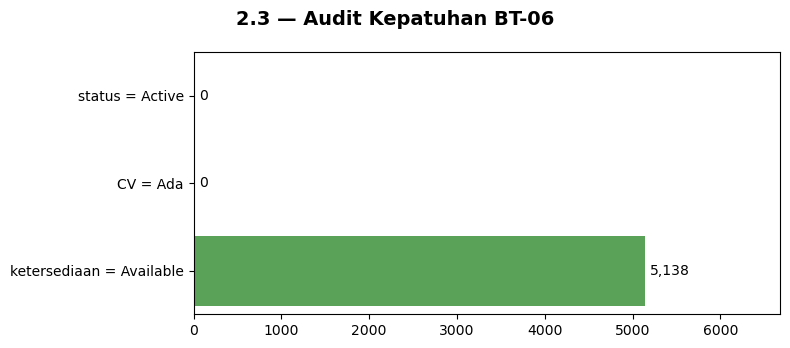

In [148]:
fig, ax = plt.subplots(figsize=(8, 3.5))
fig.suptitle("2.3 — Audit Kepatuhan BT-06", fontsize=14, fontweight="bold")

sns.barplot(
    data=audit_df,
    x="jumlah_pelanggaran",
    y="syarat",
    hue="syarat",
    palette="Set1",
    legend=False,
    ax=ax,
)

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xlim(0, max(audit_df["jumlah_pelanggaran"].max() * 1.3, 100))

for container in ax.containers:
    labels_txt = [f"{v:,.0f}" for v in container.datavalues]
    ax.bar_label(container, labels=labels_txt, padding=4, fontsize=10)

plt.tight_layout()
plt.show()

### 2.4 — Breakdown funnel per program_studi

In [149]:
status_student["eligible"] = (
    (status_student["status"] == "Active")
    & (status_student["CV"] == "Ada")
    & (status_student["ketersediaan"] == "Available")
)

prodi_summary = (
    status_student.groupby("program_studi")
    .agg(total_mahasiswa=("eligible", "size"), jumlah_eligible=("eligible", "sum"))
    .reset_index()
)
prodi_summary["percent_eligible"] = (
    prodi_summary["jumlah_eligible"] / prodi_summary["total_mahasiswa"] * 100
)
prodi_summary = prodi_summary.sort_values("percent_eligible", ascending=False)

# fmt: off
print(f"Rata-rata % eligible seluruh prodi: {status_student['eligible'].mean()*100:.1f}%\n")

print("Top 5 prodi (% eligible tertinggi -- 'paling siap kirim'):")
print(prodi_summary.head(5).to_string(index=False))

print("\nBottom 5 prodi (% eligible terendah -- 'paling tidak siap'):")
print(prodi_summary.tail(5).to_string(index=False))

print("\nProdi dengan mahasiswa TERBANYAK (belum tentu paling siap):")
print(prodi_summary.sort_values("total_mahasiswa", ascending=False).head(5).to_string(index=False))
# fmt: on

Rata-rata % eligible seluruh prodi: 22.7%

Top 5 prodi (% eligible tertinggi -- 'paling siap kirim'):
                program_studi  total_mahasiswa  jumlah_eligible  percent_eligible
                   Ilmu Hukum              700              280         40.000000
               Sastra Inggris              736              256         34.782609
          Ekonomi Pembangunan             1025              320         31.219512
Pendidikan Teknik Informatika             1495              434         29.030100
                    Psikologi             1014              287         28.303748

Bottom 5 prodi (% eligible terendah -- 'paling tidak siap'):
           program_studi  total_mahasiswa  jumlah_eligible  percent_eligible
             Informatika             2935              568         19.352641
Desain Komunikasi Visual             1248              240         19.230769
         Ilmu Komunikasi             1569              280         17.845762
        Sistem Informasi            

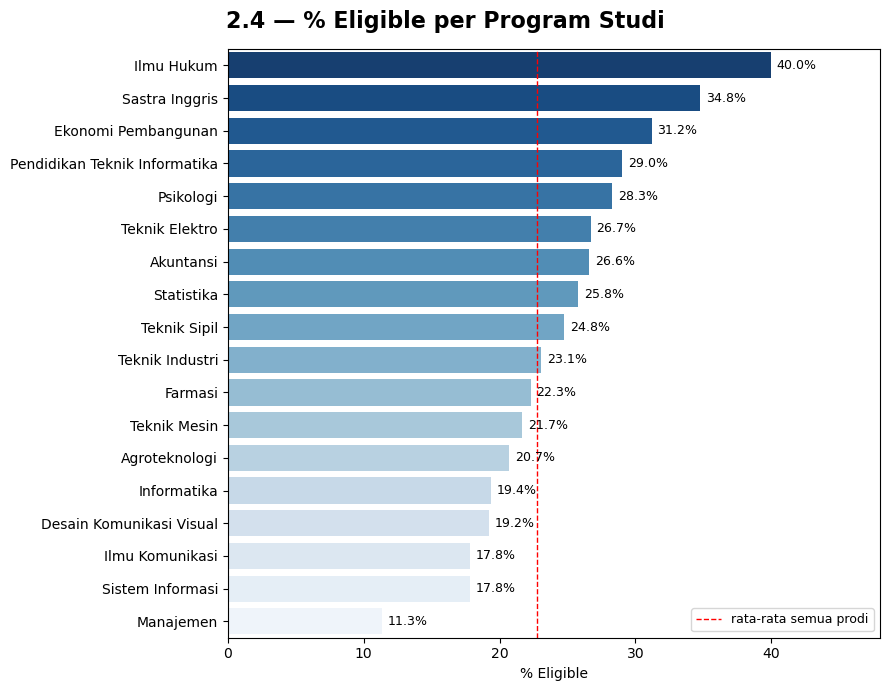

In [150]:
fig, ax = plt.subplots(figsize=(9, 7))
fig.suptitle("2.4 — % Eligible per Program Studi", fontsize=16, fontweight="bold")

sns.barplot(
    data=prodi_summary,
    x="percent_eligible",
    y="program_studi",
    hue="program_studi",
    palette="Blues_r",
    legend=False,
    ax=ax,
)

ax.axvline(
    status_student["eligible"].mean() * 100,
    color="red",
    linestyle="--",
    linewidth=1,
    label="rata-rata semua prodi",
)
ax.legend(loc="lower right", fontsize=9)

ax.set_xlabel("% Eligible")
ax.set_ylabel("")
ax.set_xlim(0, prodi_summary["percent_eligible"].max() * 1.2)

for container in ax.containers:
    if hasattr(container, "datavalues"):
        labels_txt = [f"{v:.1f}%" for v in container.datavalues]
        ax.bar_label(container, labels=labels_txt, padding=4, fontsize=9)

plt.tight_layout()
plt.show()

### 2.5 — Cross-tab CV × portofolio

In [151]:
crosstab_counts = pd.crosstab(status_student["CV"], status_student["portofolio"])
crosstab_pct = (
    pd.crosstab(status_student["CV"], status_student["portofolio"], normalize="all")
    * 100
)

print("Jumlah (n):")
print(crosstab_counts)
print("\nPersentase dari total 25.000:")
print(crosstab_pct.round(1))

n_cv_no_portfolio = crosstab_counts.loc["Ada", "Tidak Ada"]
pct_cv_no_portfolio = crosstab_pct.loc["Ada", "Tidak Ada"]

print(
    f"\n>>> Sorotan: CV Ada tapi portofolio Tidak Ada = {n_cv_no_portfolio:,} mahasiswa ({pct_cv_no_portfolio:.1f}% dari total)"
)
print("    -> populasi ini SUDAH siap dikirim (CV lengkap), tapi berisiko")
print("       tertahan kalau ada request yang mensyaratkan portofolio.")

print(
    """
CATATAN PENTING:
talent_request TIDAK punya kolom atau sinyal teks (deskripsi_requirement)
yang menyebutkan syarat portofolio secara eksplisit per-request. Jadi
crosstab ini TIDAK BISA dipakai untuk klaim "sekian % pengiriman melanggar
syarat portofolio" -- itu tidak bisa diverifikasi dari data yang tersedia.

Angka di atas murni gambaran KESIAPAN POPULASI (readiness signal), bukan
audit kepatuhan terhadap permintaan spesifik. Relevan sebagai early-warning
untuk CDC: kelompok "CV Ada, portofolio Tidak Ada" perlu didorong melengkapi
portofolio, untuk berjaga-jaga jika ada request yang mensyaratkannya.
"""
)

Jumlah (n):
portofolio    Ada  Tidak Ada
CV                          
Ada         12810       8513
Tidak Ada    2210       1467

Persentase dari total 25.000:
portofolio   Ada  Tidak Ada
CV                         
Ada         51.2       34.1
Tidak Ada    8.8        5.9

>>> Sorotan: CV Ada tapi portofolio Tidak Ada = 8,513 mahasiswa (34.1% dari total)
    -> populasi ini SUDAH siap dikirim (CV lengkap), tapi berisiko
       tertahan kalau ada request yang mensyaratkan portofolio.

CATATAN PENTING:
talent_request TIDAK punya kolom atau sinyal teks (deskripsi_requirement)
yang menyebutkan syarat portofolio secara eksplisit per-request. Jadi
crosstab ini TIDAK BISA dipakai untuk klaim "sekian % pengiriman melanggar
syarat portofolio" -- itu tidak bisa diverifikasi dari data yang tersedia.

Angka di atas murni gambaran KESIAPAN POPULASI (readiness signal), bukan
audit kepatuhan terhadap permintaan spesifik. Relevan sebagai early-warning
untuk CDC: kelompok "CV Ada, portofolio Tidak Ada" p

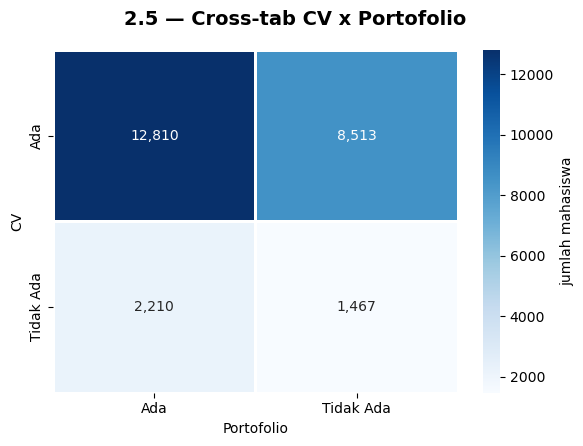

In [152]:
fig, ax = plt.subplots(figsize=(6, 4.5))
fig.suptitle("2.5 — Cross-tab CV x Portofolio", fontsize=14, fontweight="bold")

sns.heatmap(
    crosstab_counts,
    annot=True,
    fmt=",d",
    cmap="Blues",
    cbar_kws={"label": "jumlah mahasiswa"},
    ax=ax,
    linewidths=1,
    linecolor="white",
)

ax.set_xlabel("Portofolio")
ax.set_ylabel("CV")

plt.tight_layout()
plt.show()

### 2.6 — IPK: Available vs Tidak Aktif

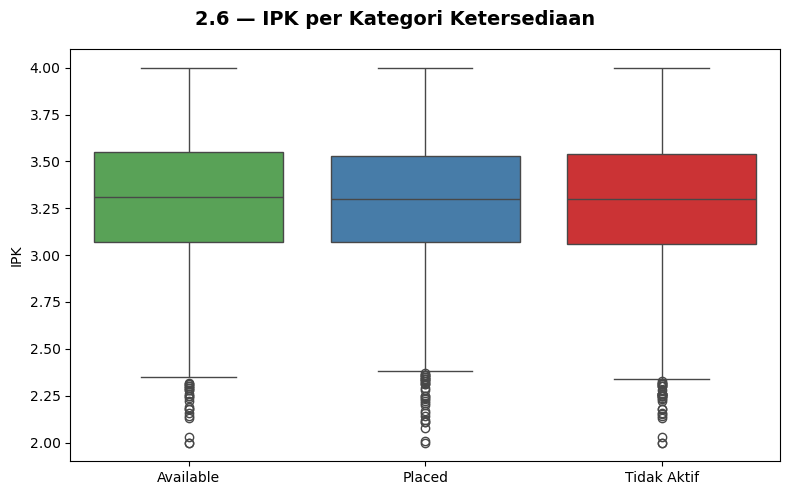

In [153]:
fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle("2.6 — IPK per Kategori Ketersediaan", fontsize=14, fontweight="bold")

order = (
    status_student.groupby("ketersediaan")["IPK"]
    .median()
    .sort_values(ascending=False)
    .index
)

sns.boxplot(
    data=status_student,
    x="ketersediaan",
    y="IPK",
    hue="ketersediaan",
    palette="Set1",
    legend=False,
    order=order,
    ax=ax,
)

ax.set_xlabel("")
ax.set_ylabel("IPK")

plt.tight_layout()
plt.show()

In [154]:
median_ipk = (
    status_student.groupby("ketersediaan")["IPK"].median().sort_values(ascending=False)
)
mean_ipk = (
    status_student.groupby("ketersediaan")["IPK"].mean().sort_values(ascending=False)
)
count_ipk = status_student.groupby("ketersediaan")["IPK"].size()

summary = pd.DataFrame(
    {
        "n": count_ipk,
        "median_IPK": median_ipk,
        "mean_IPK": mean_ipk.round(2),
    }
).sort_values("median_IPK", ascending=False)
print(summary)

tertinggi = median_ipk.idxmax()
terendah = median_ipk.idxmin()
selisih = median_ipk.max() - median_ipk.min()

print(f"\n>>> Median IPK tertinggi: '{tertinggi}' ({median_ipk.max():.2f})")
print(f">>> Median IPK terendah : '{terendah}' ({median_ipk.min():.2f})")
print(f">>> Selisih median      : {selisih:.2f}")

if "Tidak Aktif" in median_ipk.index:
    if terendah == "Tidak Aktif":
        print("\n>>> Kesimpulan: 'Tidak Aktif' memang punya median IPK PALING RENDAH")
        print("    -> ada indikasi korelasi (meski tidak berarti sebab-akibat).")
    else:
        print("\n>>> Kesimpulan: 'Tidak Aktif' BUKAN yang median IPK-nya paling rendah")
        print("    -> tidak ada indikasi korelasi kuat antara ketersediaan dan IPK.")

                 n  median_IPK  mean_IPK
ketersediaan                            
Available     7135        3.31       3.3
Placed        9301        3.30       3.3
Tidak Aktif   8564        3.30       3.3

>>> Median IPK tertinggi: 'Available' (3.31)
>>> Median IPK terendah : 'Placed' (3.30)
>>> Selisih median      : 0.01

>>> Kesimpulan: 'Tidak Aktif' BUKAN yang median IPK-nya paling rendah
    -> tidak ada indikasi korelasi kuat antara ketersediaan dan IPK.


### 2.7 — Top tools/skill kelompok eligible

In [155]:
status_student["eligible"] = (
    (status_student["status"] == "Active")
    & (status_student["CV"] == "Ada")
    & (status_student["ketersediaan"] == "Available")
)

eligible_df = status_student[status_student["eligible"]].copy()

eligible_df["tools_list"] = eligible_df["tools"].str.split(",")
tools_exploded = eligible_df.explode("tools_list")
tools_exploded["tools_list"] = tools_exploded["tools_list"].str.strip()

tools_counts = tools_exploded["tools_list"].value_counts()

print(f"Basis: {len(eligible_df):,} mahasiswa eligible (Active+CV+Available)")
print(f"Jumlah tools unik yang disebut: {len(tools_counts)}")
print(f"Total mention tools (setelah explode): {len(tools_exploded):,}\n")

top_n = 20
print(f"Top {top_n} tools/skill:")
print(tools_counts.head(top_n))

Basis: 5,687 mahasiswa eligible (Active+CV+Available)
Jumlah tools unik yang disebut: 80
Total mention tools (setelah explode): 19,931

Top 20 tools/skill:
tools_list
Python              1214
Excel               1200
SQL                  989
SPSS                 761
SAP                  682
Power BI             631
MATLAB               597
AutoCAD              524
Microsoft Office     500
Tableau              439
R                    437
Figma                427
JavaScript           369
Canva                360
Git                  329
WordPress            327
Java                 320
SolidWorks           318
Mendeley             275
Google Analytics     272
Name: count, dtype: int64


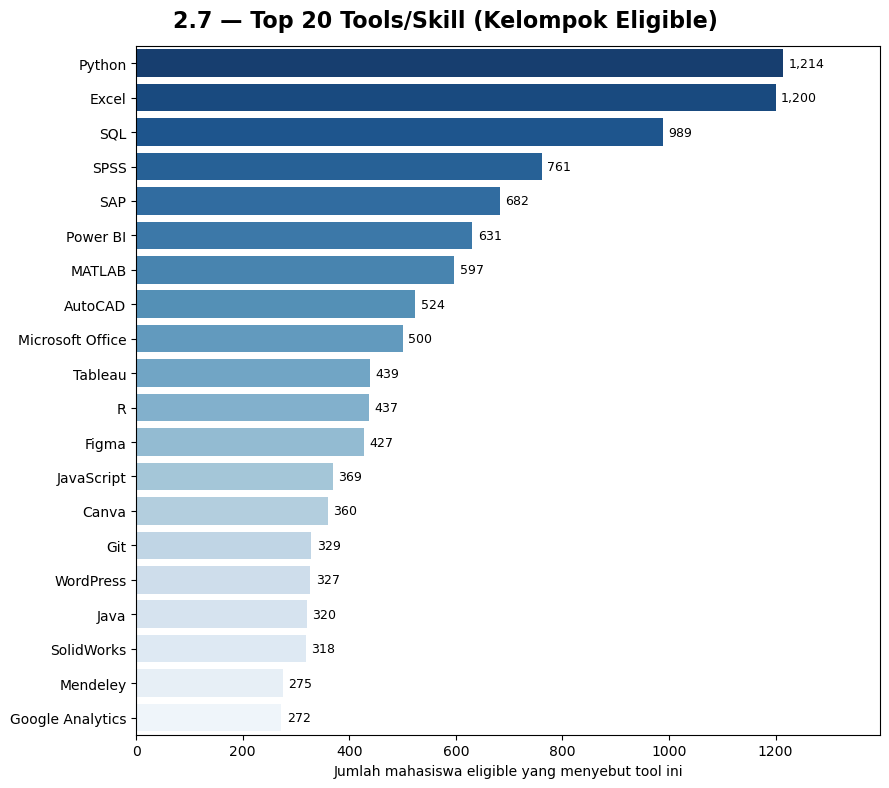

In [156]:
top_tools = tools_counts.head(20)

fig, ax = plt.subplots(figsize=(9, 8))
fig.suptitle(
    "2.7 — Top 20 Tools/Skill (Kelompok Eligible)", fontsize=16, fontweight="bold"
)

sns.barplot(
    x=top_tools.values,
    y=top_tools.index,
    hue=top_tools.index,
    palette="Blues_r",
    legend=False,
    ax=ax,
)

ax.set_xlabel("Jumlah mahasiswa eligible yang menyebut tool ini")
ax.set_ylabel("")
ax.set_xlim(0, top_tools.max() * 1.15)

for container in ax.containers:
    if hasattr(container, "datavalues"):
        ax.bar_label(
            container,
            labels=[f"{v:,.0f}" for v in container.datavalues],
            padding=4,
            fontsize=9,
        )

plt.tight_layout()
plt.show()